<h1 style="text-align: center;"> Python Pandas: Module 3 </h1>
<img
    style="display: block;
    margin-left: auto;
    margin-right: auto;
    width: 50%;"
    src="https://cdn.knmi.nl/assets/logo_large-1eaabc639fd87bd3867e4e1e3358711968aad57ca90d766ecdd62f93930abf3b.png" 
    alt="Our logo">
</img>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
knmi = pd.read_csv("knmi.csv")

In [100]:
knmi.head()
knmi.tail()

,STN,YYYY,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,YEAR
119,260,2020,62,72,68,111,131,175.0,170.0,204.0,152.0,113.0,89.0,55.0,117.0
120,260,2021,34,43,64,67,112,182.0,180.0,169.0,159.0,116.0,74.0,54.0,105.0
121,260,2022,53,68,73,93,140,171.0,186.0,200.0,146.0,131.0,86.0,39.0,116.0
122,260,2023,58,57,70,87,135,194.0,181.0,176.0,175.0,132.0,78.0,69.0,118.0
123,260,2024,39,82,90,108,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Stap 1: Herbenoem de kolomnamen

In [4]:
df = knmi.rename(columns={"MAR":"MRT", "MAY":"MEI","OCT":"OKT","YEAR":"JAAR"})
df

,STN,YYYY,JAN,FEB,MRT,APR,MEI,JUN,JUL,AUG,SEP,OKT,NOV,DEC,JAAR
0,260,1901,-3,-9,35,90,120,144.0,181.0,162.0,143.0,101.0,52.0,30.0,87.0
1,260,1902,47,-3,53,85,92,153.0,152.0,146.0,129.0,85.0,37.0,8.0,82.0
2,260,1903,30,57,72,56,126,140.0,153.0,150.0,140.0,109.0,56.0,9.0,92.0
3,260,1904,8,30,38,96,118,141.0,175.0,156.0,122.0,91.0,55.0,40.0,89.0
4,260,1905,13,36,60,66,117,164.0,174.0,157.0,127.0,65.0,38.0,24.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,260,2020,62,72,68,111,131,175.0,170.0,204.0,152.0,113.0,89.0,55.0,117.0
120,260,2021,34,43,64,67,112,182.0,180.0,169.0,159.0,116.0,74.0,54.0,105.0
121,260,2022,53,68,73,93,140,171.0,186.0,200.0,146.0,131.0,86.0,39.0,116.0
122,260,2023,58,57,70,87,135,194.0,181.0,176.0,175.0,132.0,78.0,69.0,118.0


# Verander de graden van 0.1 (tiende graad) naar graden

In [67]:
df.iloc[:, 2:] = df.iloc[:, 2:].values/10
df.head()

,STN,YYYY,JAN,FEB,MRT,APR,MEI,JUN,JUL,AUG,SEP,OKT,NOV,DEC,JAAR
0,260,1901,-0.3,-0.9,3.5,9.0,12.0,14.4,18.1,16.2,14.3,10.1,5.2,3.0,8.7
1,260,1902,4.7,-0.3,5.3,8.5,9.2,15.3,15.2,14.6,12.9,8.5,3.7,0.8,8.2
2,260,1903,3.0,5.7,7.2,5.6,12.6,14.0,15.3,15.0,14.0,10.9,5.6,0.9,9.2
3,260,1904,0.8,3.0,3.8,9.6,11.8,14.1,17.5,15.6,12.2,9.1,5.5,4.0,8.9
4,260,1905,1.3,3.6,6.0,6.6,11.7,16.4,17.4,15.7,12.7,6.5,3.8,2.4,8.7


# Print de hoogste gemiddelde jaartemperatuur en het desbetreffende jaar uit

In [115]:
highest_mean_temp = df.loc[df["JAAR"].idxmax(),["YYYY","JAAR"]]
highest_mean_temp
print(f"Hoogste jaargemiddelde: {highest_mean_temp["JAAR"]}°C")
print(f"Dit was in jaar: {int(highest_mean_temp["YYYY"])}")

Hoogste jaargemiddelde: 11.8°C
Dit was in jaar: 2023


In [134]:
print(f"De hoogts gemiddelde jaartemperatuur was {highest_mean_temp["JAAR"]} in het jaar {int(highest_mean_temp["YYYY"])}.")

De hoogts gemiddelde jaartemperatuur was 11.8 in het jaar 2023.


# Maak een grafiek van de gemiddelde jaartemperatuur

In [9]:
import matplotlib.pyplot as plt

In [5]:
gem_jaar_temp = df[["YYYY","JAAR"]]#.set_index("YYYY")
#gem_jaar_temp.index = pd.to_numeric(gem_jaar_temp.index, errors="coerce")
#gem_jaar_temp["JAAR"] = pd.to_numeric(gem_jaar_temp["JAAR"], errors = "coerce")
gem_jaar_temp = gem_jaar_temp.dropna()

In [130]:
gem_jaar_temp.head()

,YYYY,JAAR
0,1901,8.7
1,1902,8.2
2,1903,9.2
3,1904,8.9
4,1905,8.7


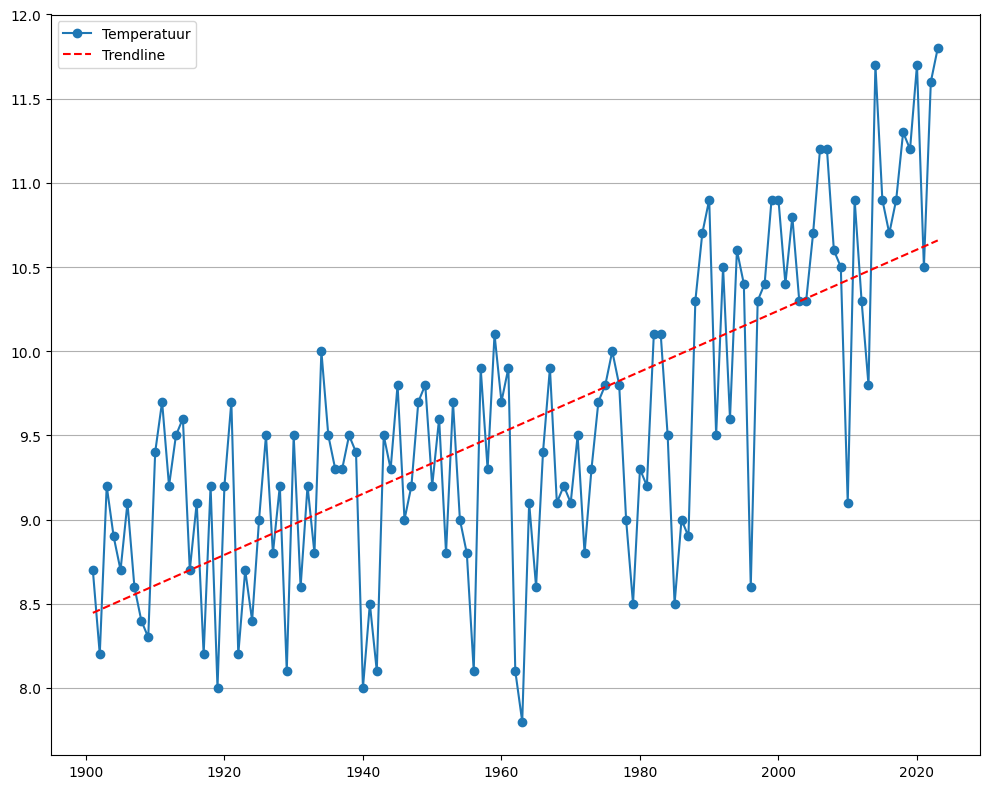

In [129]:
plt.figure(figsize=(10,8))
plt.plot(gem_jaar_temp["YYYY"], gem_jaar_temp["JAAR"], marker="o", label="Temperatuur")

z = np.polyfit(gem_jaar_temp["YYYY"], gem_jaar_temp['JAAR'], 1)
p = np.poly1d(z)
plt.plot(gem_jaar_temp["YYYY"], p(gem_jaar_temp["YYYY"]), linestyle='--', color='red', label='Trendline')

plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()